**Compare the throughput curve extracted from ScopeSim to the analytic ETC throughput curve.**

Either send in a uniform illumination source with a constant flux of 1 photlam defined over the slit aperture, or a delta function source, and extract the resulting bandpass summed along the slit spatial axis.

In [1]:
import scopesim as sim
from scopesim.source.source_templates import uniform_illumination
from scopesim.source.source import Source
sim.link_irdb("../..")

import numpy as np
from astropy.wcs import WCS
from astropy import units as u
import matplotlib.pyplot as plt
from synphot import SourceSpectrum, Observation
from synphot.units import PHOTLAM
from synphot.models import ConstFlux1D

import sys
sys.path.append("../../../../uvex-mission/uvex-mission")
import uvex
from uvex.sensitivity import config, filters, spectrometer

config.dump_defaults() 
UVEX = config.UVEX(default=True)

The collecting area is slightly different in the ETC than it is in ScopeSim, where it is calculated from the size of the largest mirror in the optical train (the first one). For an apples-to-apples comparison we'll manually set the ScopeSim telescope area. We will also choose a similar spectral bin width.

All detector effects are turned off, and the SpacecraftPointing effect is optionally set at the same FWHM as in the ETC slit throughput calculation.

In [2]:
# Set up
etc_area = np.pi * (0.75*u.m*0.5)**2
pixel_scale = 0.8 * u.arcsec
bin_width = 1e-04 * u.um # MUST BE 1 ANGSTROM for comparison to ETC throughput

cmdlss = sim.UserCommands(use_instrument="UVEX", set_modes=['lss'])

cmdlss["!SIM.spectral.spectral_bin_width"] = bin_width.value
cmdlss["!SIM.spectral.spectral_resolution"] = 5000
cmdlss["!SIM.computing.oversampling_x"] = 10
cmdlss["!SIM.computing.oversampling_y"] = 10
cmdlss["!SIM.computing.crop_y"] = [-20., 20.]
cmdlss["!TEL.area"] = etc_area  # m^2

optlss = sim.OpticalTrain(cmdlss)
om = optlss.optics_manager

# Set oversampling
om['oversample_image'].meta['include'] = True
om['downsample_image'].meta['include'] = True

# Toggle on/off the new PSF effects
om['slit_psf'].meta['include'] = True
om['detector_psf'].meta['include'] = True

# And turn off detector effects for now
om['lss_dark_current'].meta['include'] = False
om['lss_shot_noise'].meta['include'] = False
om['lss_readout_noise'].meta['include'] = False
om['lss_ad_conversion'].meta['include'] = False # keep in electrons

# Same as assumed in ETC
om['spacecraft_pointing'].meta['fwhm'] = 2
om['spacecraft_pointing'].meta['include'] = True

# The detector gain was also changed in the config to be 1.0
# ...can we set this from a notebook?

z_levels = np.arange(0, 1000, 100)
for z in z_levels:
    effs = om.get_z_order_effects(int(z))
    print(f"\nz-range {z}..{z+99}")
    for eff in effs:
        el = next(oe for oe in om.optical_elements if eff in oe.effects)
        print(f"{el.meta['name']:<20} | {eff.display_name:<20} | {eff.__class__.__name__:<20} | z_order={eff.z_order}")


py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits

z-range 0..99
UVEX                 | ota_surface_list     | SurfaceList          | z_order=(20, 120, 520)
LSS                  | relay_optics         | SurfaceList          | z_order=(20, 120, 520)
LSS                  | surfaces             | SurfaceList          | z_order=(20, 120, 520)
LSS                  | slit_geometry        | UVEXSlitMask         | z_order=(27, 227, 627)
LSS                  | spectral_traces      | SpectralTraceList    | z_order=(70, 270, 670)
uvex_lss_detector    | LSS_Detector         | DetectorList         | z_order=(90, 290, 390, 490)

z-range 100..199
uvex_lss_detector    | si_bandgap           | QuantumEfficiencyCurve | z_order=(113, 513)
UVEX  

Use a uniform flux source covering the entire slit aperture, or use a uniform flux point source.

In [3]:
lam_array = np.arange(0.115, 0.355, 0.001)*u.um 
sp = SourceSpectrum(ConstFlux1D, amplitude=1*PHOTLAM)
#constant_source = uniform_illumination(xs=[12599., 12601.], ys=[-1800., 1800.], pixel_scale=0.8, spectrum=sp)
constant_source = Source(x=[12600.], y=[0.], spectra = sp, weight=[1.0], ref=[0])

py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:211: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects:   0%|          | 0/8 [00:00<?, ?it/s]

 SpacecraftPointing effect convolution: 100%|██████████| 2339/2339 [00:10<00:00, 220.94it/s]


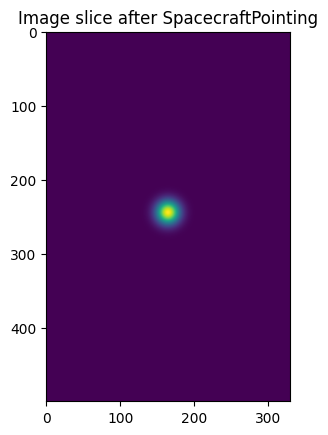

 Slit PSF Convolution: 640it [00:37, 17.26it/s]             


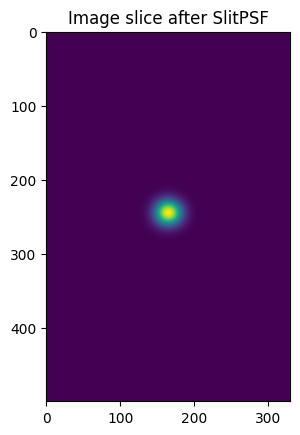

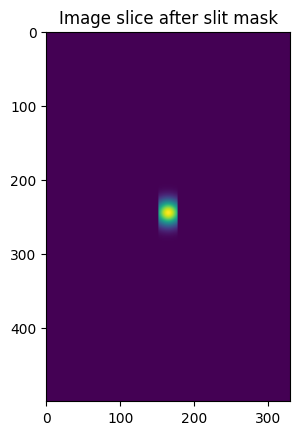

astar.scopesim.effects.apertures - Calculated slit throughput: 0.7016845653024347
astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /Users/eshread/Desktop/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat
astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 125522 negative pixels


 LSS Detector PSF Convolution: 3520it [00:16, 218.33it/s]             


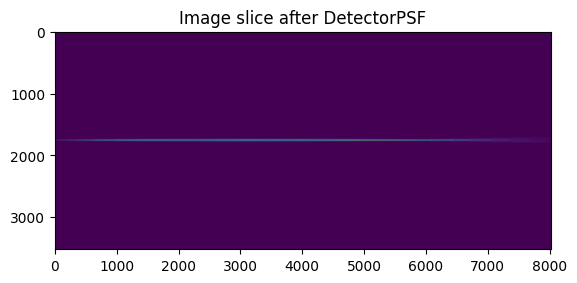

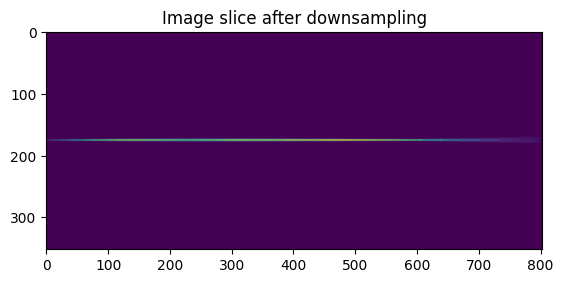

astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
astar.scopesim.detector.detector_manager - Extracting from 2 detectors...


In [4]:
# Run the simulation
optlss.observe(constant_source, update=True)
hdulist_lss_ = optlss.readout()[0]

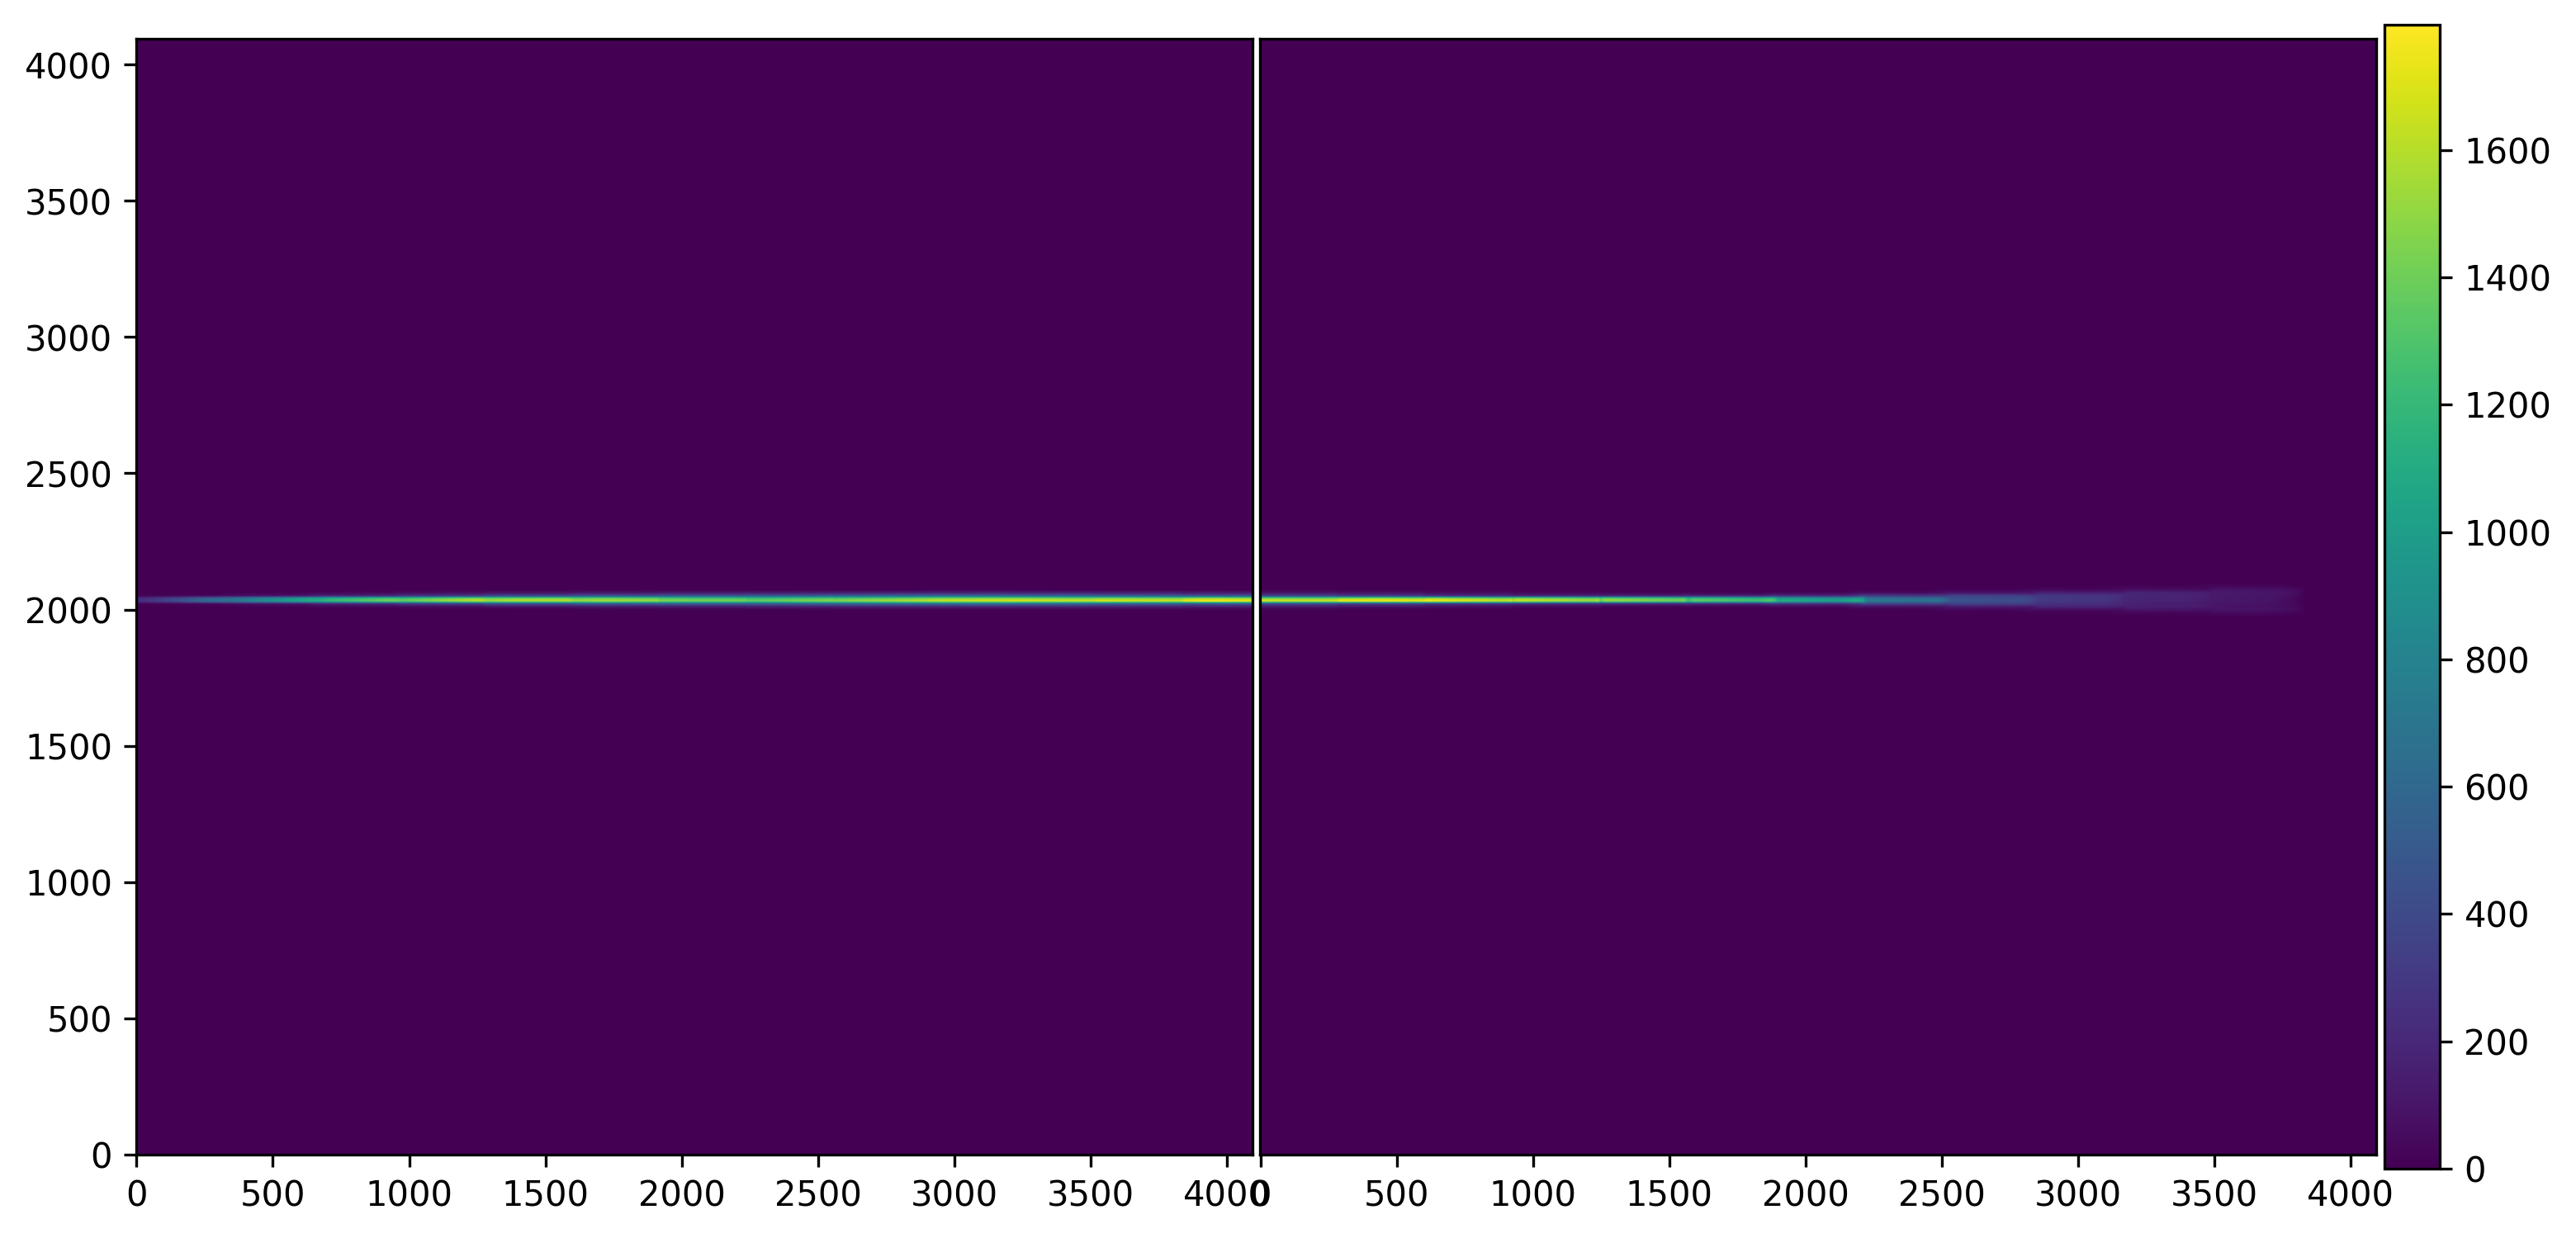

In [5]:
# Plot the output image
fig, axs = plt.subplots(ncols=3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]}, dpi=300)
ax0, ax1, cax = axs
ax0.tick_params(axis="both", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_yticks([])

im0 = ax0.imshow(hdulist_lss_[1].data, origin='lower')
im1 = ax1.imshow(hdulist_lss_[2].data, origin='lower')

cbar = fig.colorbar(im1, cax=cax)
plt.subplots_adjust(wspace=0.01)
plt.show()

In [6]:
# Now rectify the spectra (get back into wavelengths/slit positions)
tracelist = optlss["spectral_traces"]
rectified = tracelist.rectify_traces(hdulist_lss_, xi_min=-1800., xi_max=1800., bin_width=bin_width.value)

astar.scopesim.effects.spectral_trace_list - Full wavelength range: 0.12 .. 0.35 um


 Traces:   0%|          | 0/1 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Rectifying UVIM_LSS_trace (0.12 .. 0.35 um)


Ratio of raw and rectified image electron counts (should be 1): 1.00


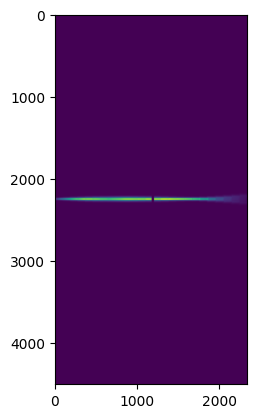

In [7]:
# Verify flux is conserved during rectification
raw_flux = (float(hdulist_lss_[1].data.sum()) + float(hdulist_lss_[2].data.sum())) * hdulist_lss_[1].header['CDELT1D'] * hdulist_lss_[1].header['CDELT2D'] # multiply by pixel area to get result in electrons
rectified_flux = rectified[1].data.sum() * bin_width.value * pixel_scale.value
print(f"Ratio of raw and rectified image electron counts (should be 1): {rectified_flux / raw_flux:.2f}")

plt.imshow(rectified[1].data)
plt.show()

**Load the LSS bandpass from the ETC.**

The slit throughput for the spectrograph bandpass in the ETC is calculated assuming a point source. If considering a uniform illumination source over the whole aperture, we should divide out by this factor.

In [8]:
slit_thru = UVEX.SLIT_THROUGHPUT
lss_bandpass_etc_file = "../../../uvex-mission/uvex/sensitivity/notebooks/bandpass_files/lss_bandpass.txt"

lss_bandpass_etc_data = np.loadtxt(lss_bandpass_etc_file)
lss_bandpass_etc_wave = (lss_bandpass_etc_data[:,0] * u.AA).value
lss_bandpass_etc_throughput = lss_bandpass_etc_data[:,1]

exptime = optlss.cmds["!OBS.dit"] * optlss.cmds["!OBS.ndit"]

w = WCS(rectified[1].header)
n_lam = rectified[1].data.shape[1]
n_xi = rectified[1].data.shape[0]
pix_x = np.arange(n_lam) 
pix_y = np.zeros(n_lam) 
lam_world = w.all_pix2world(np.column_stack([pix_x, pix_y]), 0)
lam = lam_world[:, 0] * (u.m).to(u.AA)

nonzero_xi, nonzero_lam = np.where(rectified[1].data > 0) 
nonzero_xi, nonzero_lam = np.unique(nonzero_xi), np.unique(nonzero_lam)

# Sum along the slit axis. This appears to already be divided out by the exposure time in sec...
trace1 = rectified[1].data[nonzero_xi, :].sum(axis=0)

# Get the total count rate of the input
input_countrate = 1 * (u.photon / u.s / u.cm**2 / u.AA) * bin_width.to(u.AA) * etc_area.to(u.cm**2)
trace1_dimensionless = trace1 / input_countrate # less than 1% error in normalization when Slit and Detector PSFs are turned off

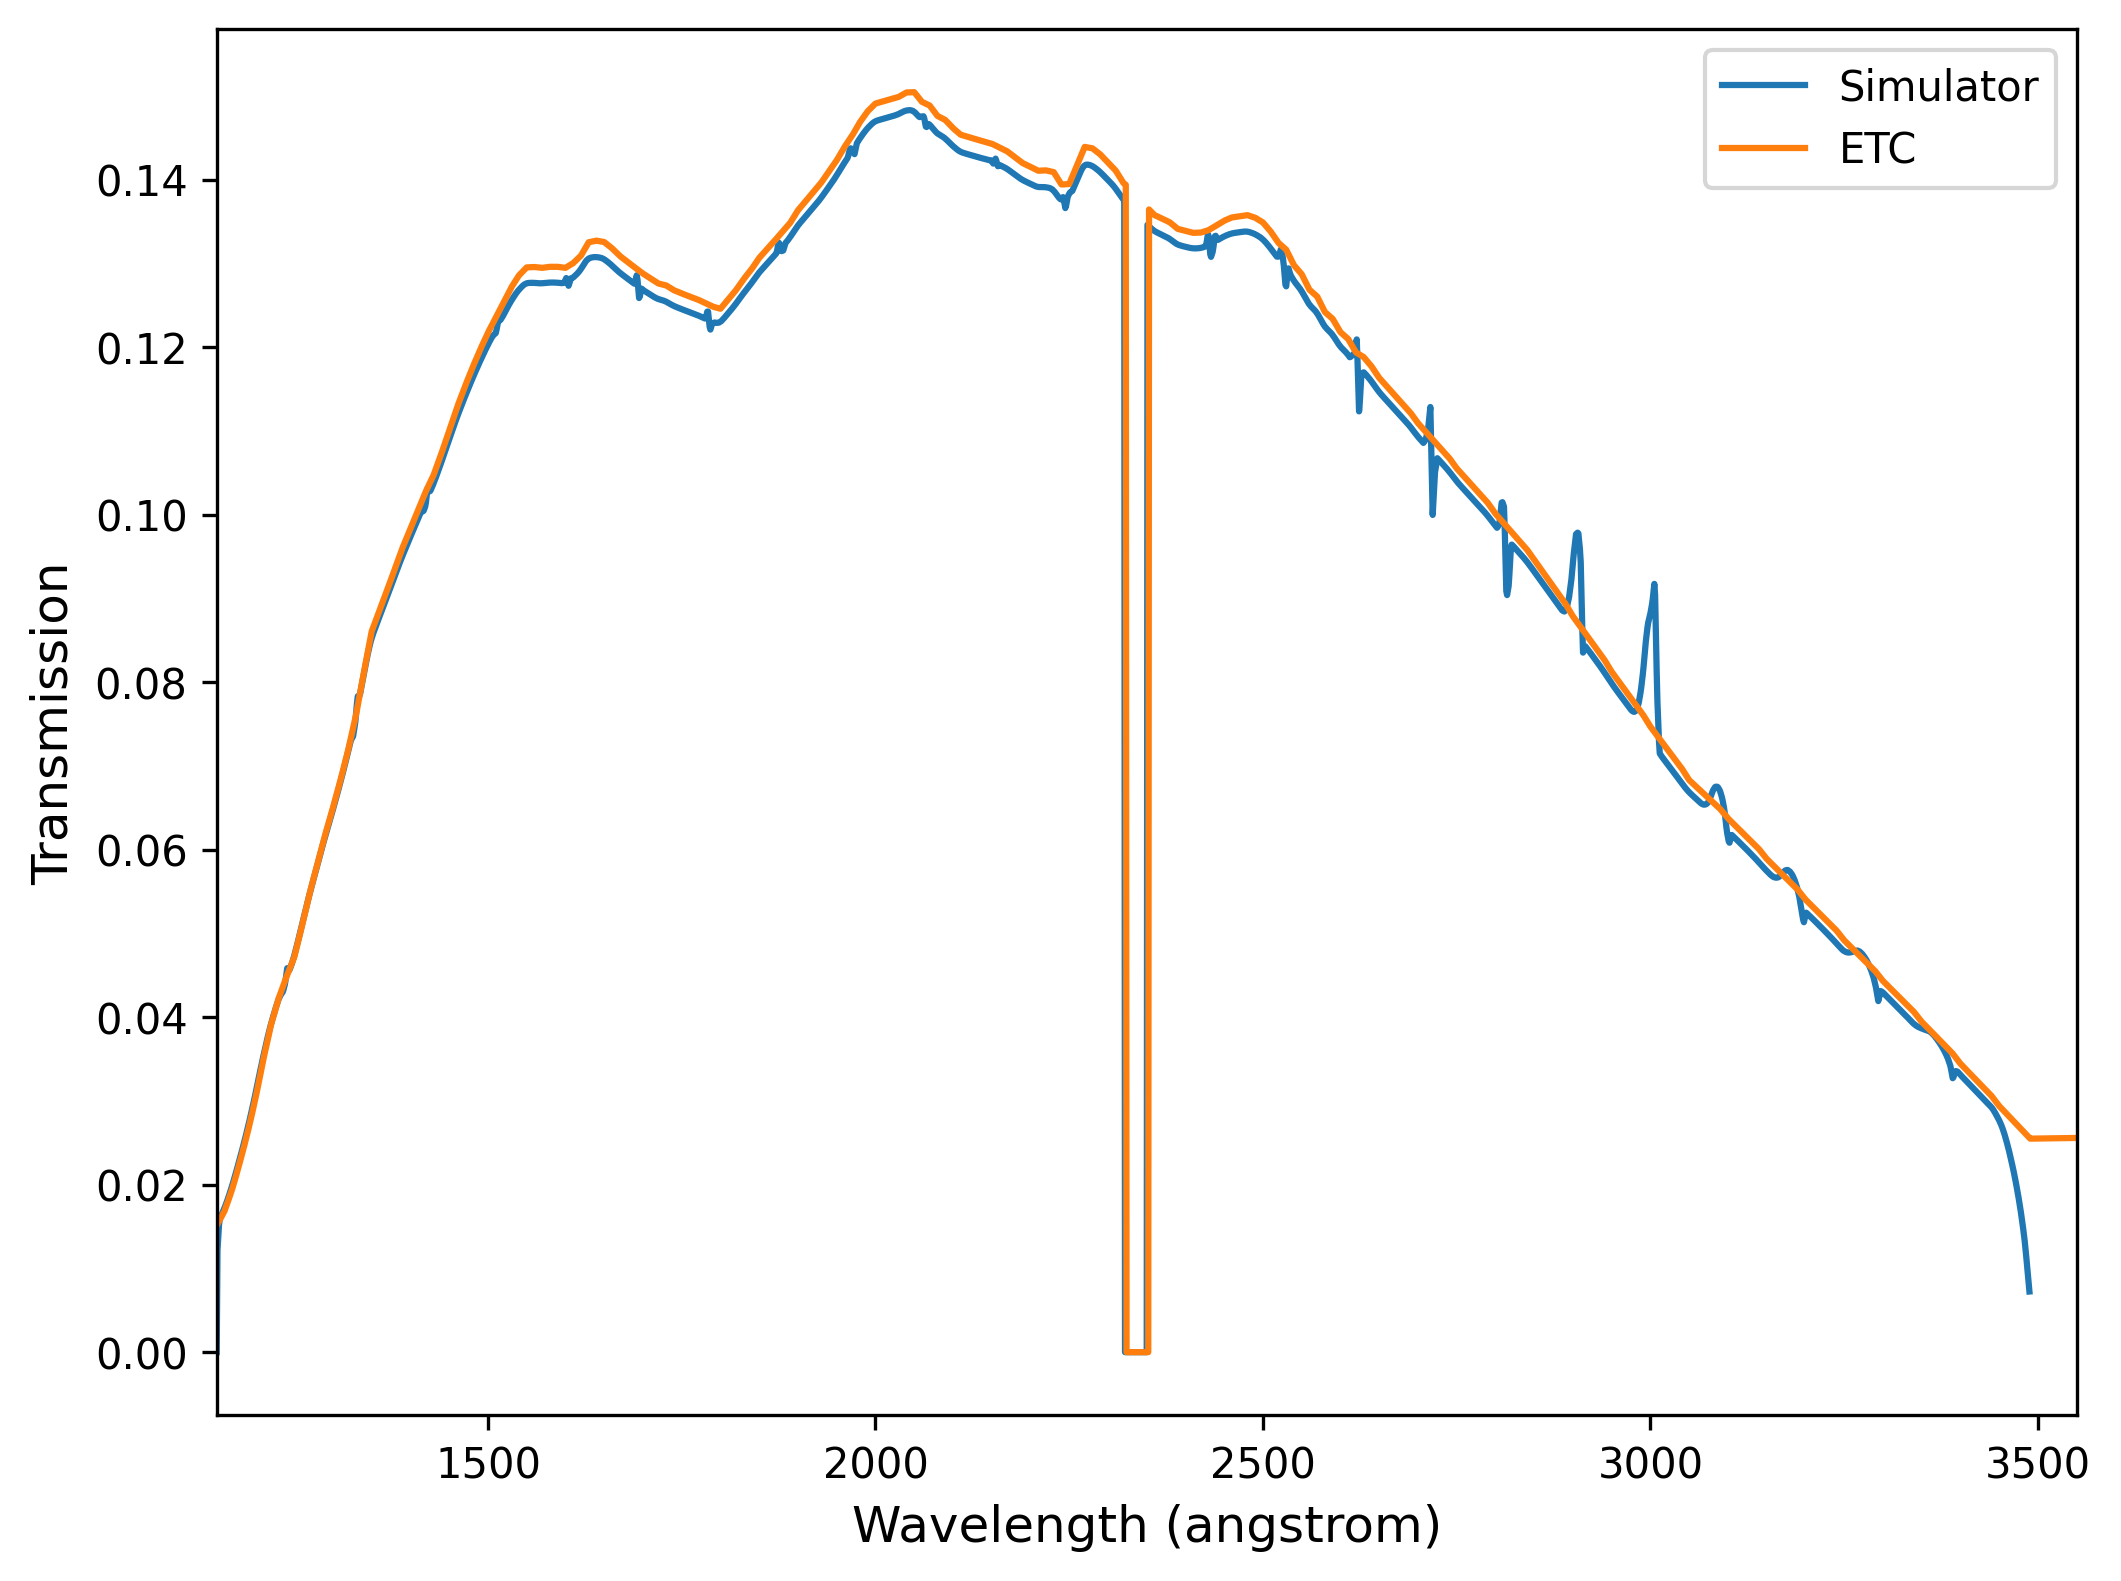

In [9]:
# TODO: how to minimize the ringing effect? definitely related to DetectorPSF. remove in post processing?

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1_dimensionless) / exptime, label="Simulator")
ax.plot(lss_bandpass_etc_wave, lss_bandpass_etc_throughput, label='ETC')
ax.set_xlabel("Wavelength (angstrom)", fontsize=12)
ax.set_ylabel("Transmission", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(1150, 3550)
plt.show()

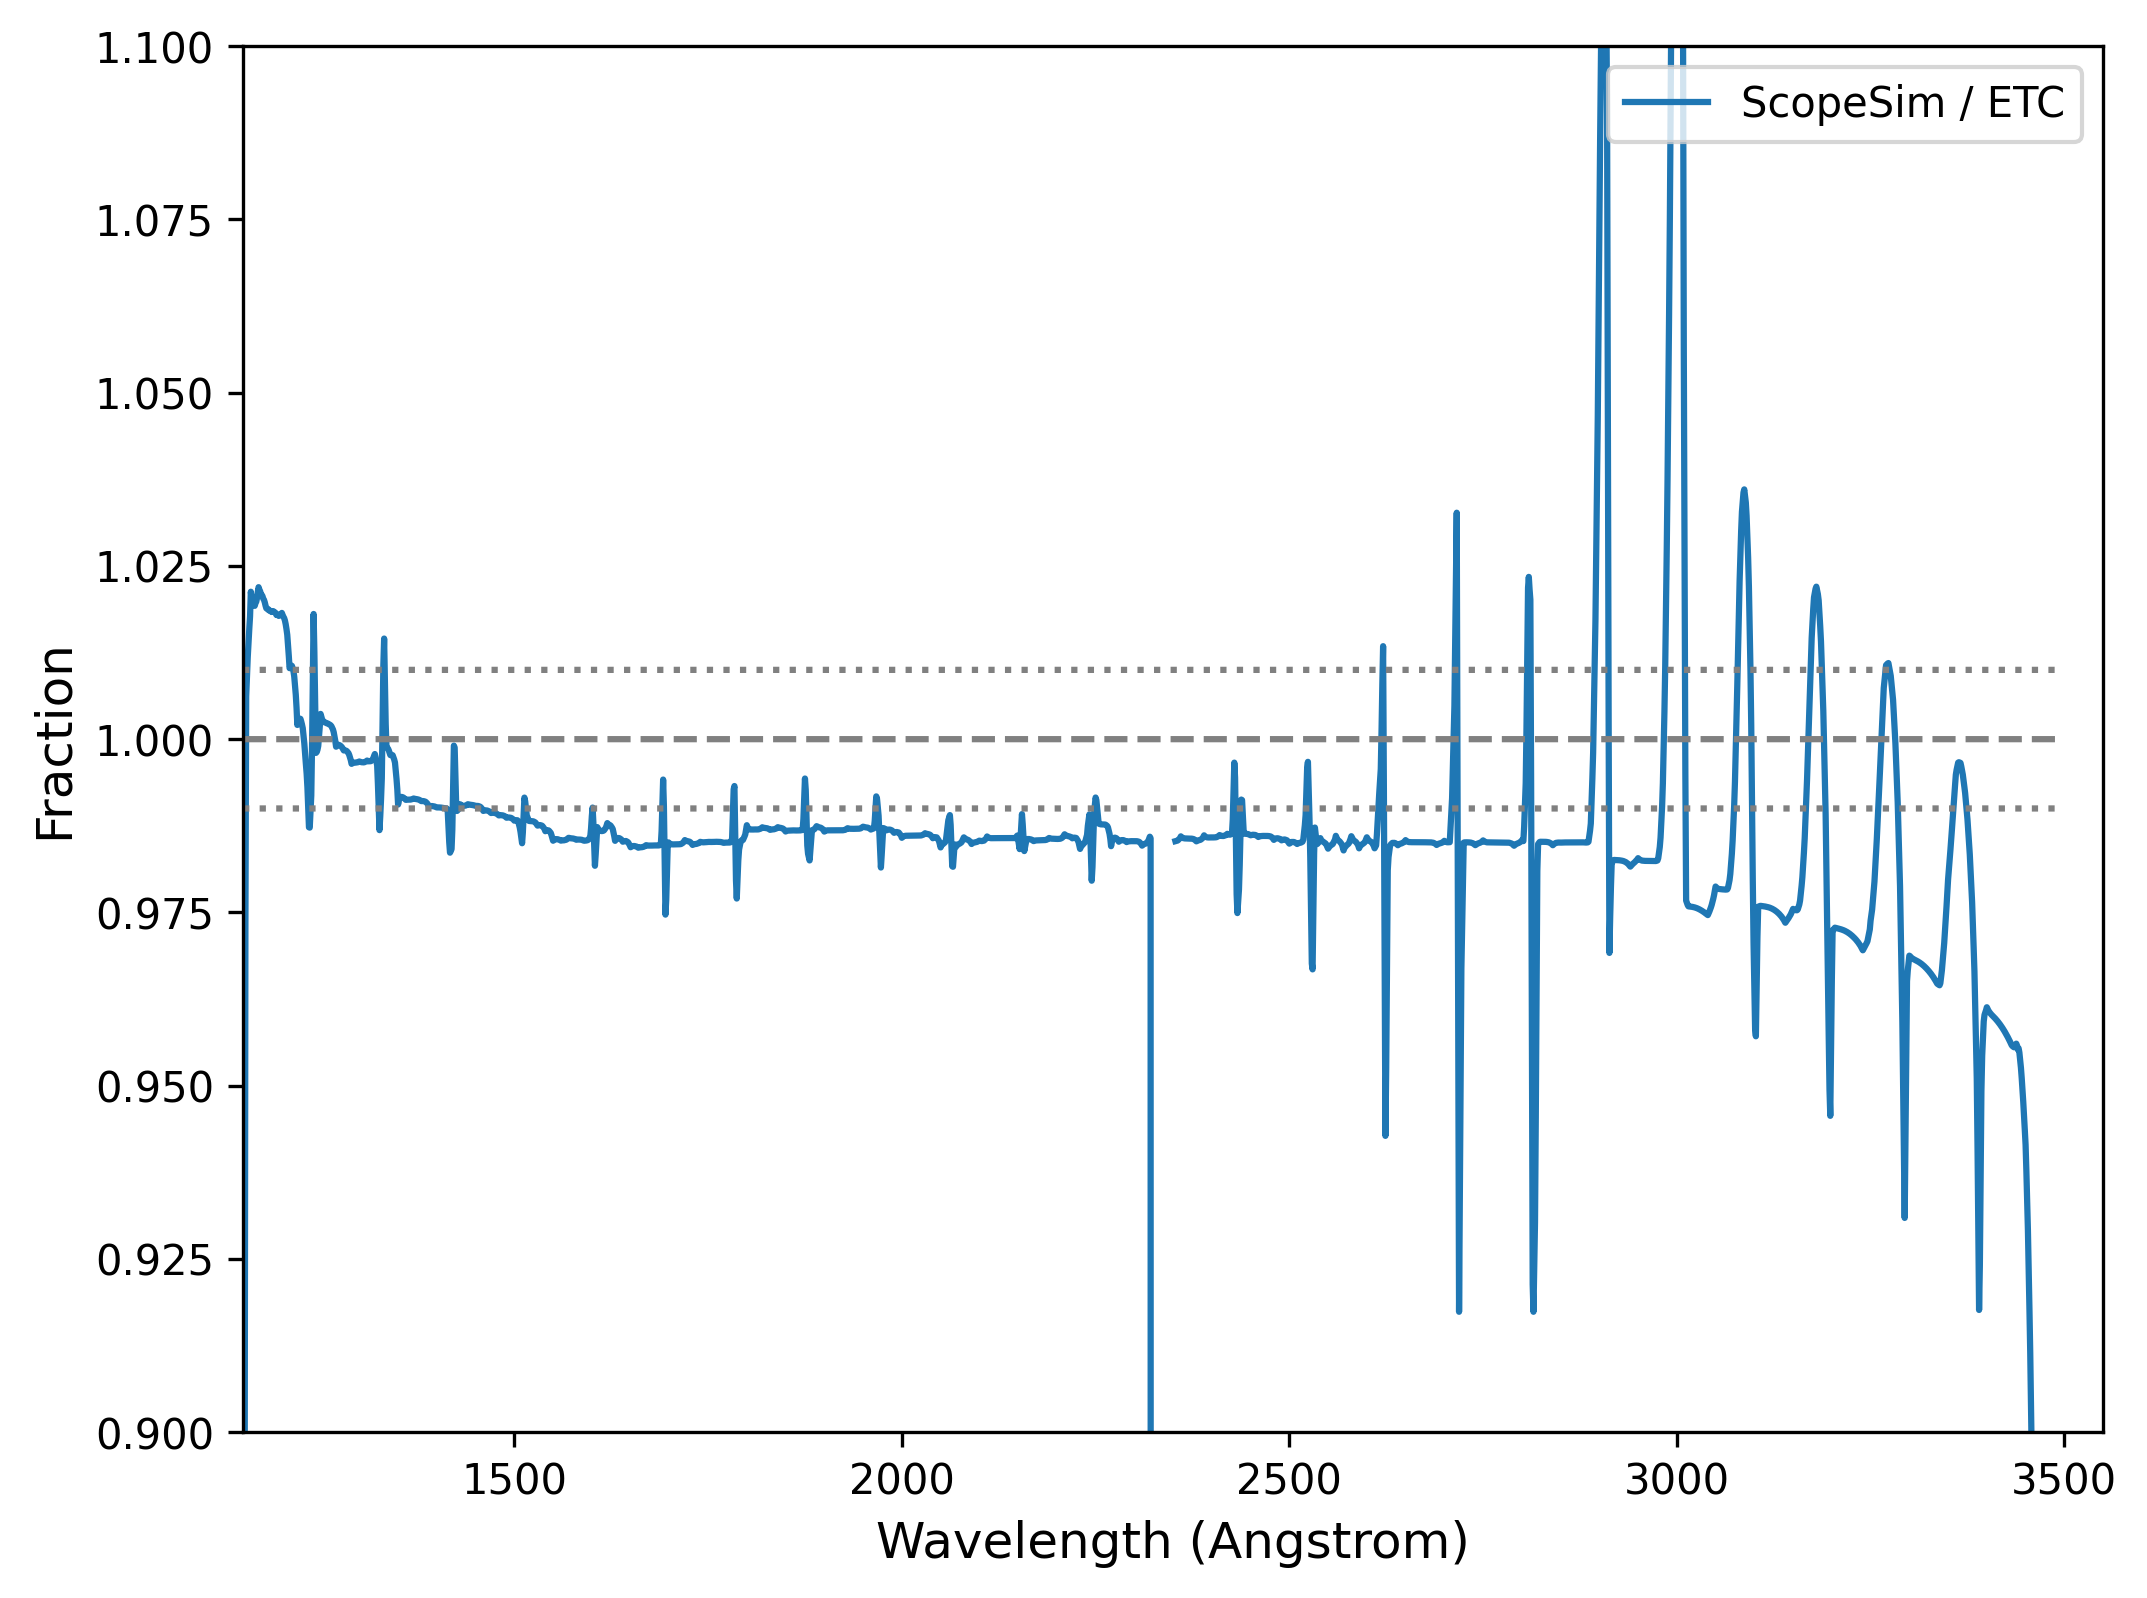

In [11]:
etc_inband = lss_bandpass_etc_throughput[(lss_bandpass_etc_wave >= 1150.) & (lss_bandpass_etc_wave <= 3489.)]
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1_dimensionless)/exptime/np.array(etc_inband), label="ScopeSim / ETC")
ax.plot(lam, np.ones_like(lam), linestyle='--', color='grey')
ax.plot(lam, np.array([0.99]*len(lam)), linestyle=':', color='grey')
ax.plot(lam, np.array([1.01]*len(lam)), linestyle=':', color='grey')
ax.set_xlabel("Wavelength (Angstrom)", fontsize=12)
ax.set_ylabel("Fraction", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(1150, 3550)
plt.ylim(0.9, 1.1)
plt.show()